# Shape Optimisation

Find the cantilever length whose tip deflects to a target value under a fixed
load, driven by the analytical sensitivities rather than finite differences.

In [1]:
import contextlib, io

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from fem2d.meshers import Mesh
from fem2d.solvers import FEMSolvers

quiet = lambda: contextlib.redirect_stdout(io.StringIO())

## Problem

A 5B cantilever with fixed height and load. Length is the only design variable,
and it is design variable 0 of `SimpleBeam`, so its sensitivity is `dUdx[:, 0]`.

In [2]:
E, v, t, plane = 210000.0, 0.3, 1.0, 1
el_num, Height, Load = 20, 0.5, -25.0
Target = -2.0


def TipAndGradient(Length):
    """Tip deflection and its analytical derivative with respect to Length."""
    m = Mesh(E, v, t, plane, '5B')
    m.SimpleBeam(el_num, float(Length), Height, Load)
    with quiet():
        FEMSolvers.LinearSolver(m, Sensitivity=True)
    return m.U[-1, 0], m.dUdx[-1, 0]


for L in (6.0, 8.0, 10.0, 12.0):
    u, dudL = TipAndGradient(L)
    print(f"L={L:5.1f}   tip={u: .5f}   dtip/dL={dudL: .5f}")

L=  6.0   tip=-0.75236   dtip/dL=-0.37473


L=  8.0   tip=-1.77901   dtip/dL=-0.66577


L= 10.0   tip=-3.47088   dtip/dL=-1.03995


L= 12.0   tip=-5.99424   dtip/dL=-1.49727


## The gradient is exact

Central differences approach the analytical value as the step shrinks, then turn
back up as cancellation takes over. The analytical derivative has no such floor,
which is the reason to use it.

In [3]:
L0 = 9.0
_, Analytic = TipAndGradient(L0)

print(f"analytic  {Analytic:.10f}\n")
print(f"{'step':>8}{'central FD':>16}{'rel err':>11}")
for step in (1e-1, 1e-2, 1e-3, 1e-4, 1e-6, 1e-8):
    FD = (TipAndGradient(L0 + step)[0] - TipAndGradient(L0 - step)[0])/(2*step)
    print(f"{step:>8.0e}{FD:>16.10f}{abs(Analytic - FD)/abs(FD):>11.1e}")

analytic  -0.8424693817

    step      central FD    rel err


   1e-01   -0.8425040244    4.1e-05


   1e-02   -0.8424697280    4.1e-07


   1e-03   -0.8424693885    8.1e-09


   1e-04   -0.8424693801    1.9e-09


   1e-06   -0.8424666202    3.3e-06


   1e-08   -0.8384904993    4.7e-03


## Objective

Scaled squared error, so the objective and its gradient are order one:

$$f(L) = r^2, \qquad r = \frac{u_{tip}(L) - u^*}{u^*}, \qquad
\frac{df}{dL} = \frac{2r}{u^*}\frac{du_{tip}}{dL}$$

`minimize` is given `jac=True`, so the objective returns the value and the
gradient together and the optimiser never finite differences the model.

In [4]:
Path = []


def Objective(x):
    u, dudL = TipAndGradient(x[0])
    r = (u - Target)/Target
    Path.append((x[0], u))
    return r**2, np.array([2*r*dudL/Target])


Result = minimize(Objective, x0=[12.0], jac=True, method='L-BFGS-B',
                  bounds=[(2.0, 20.0)], options=dict(ftol=1e-15, gtol=1e-12))

LengthOpt = Result.x[0]
print(Result.message)
print(f"L*          = {LengthOpt:.6f}")
print(f"tip at L*   = {TipAndGradient(LengthOpt)[0]:.9f}    target {Target}")
print(f"solves used = {Result.nfev}")

CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
L*          = 8.319046


tip at L*   = -2.000000000    target -2.0
solves used = 9


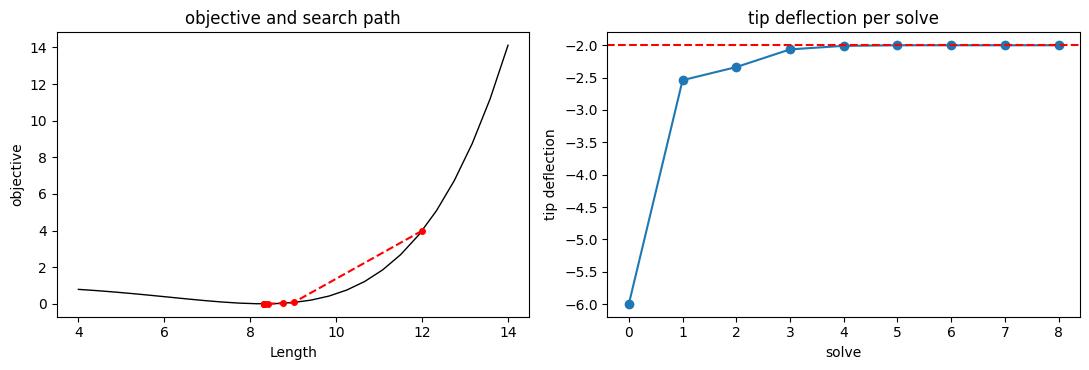

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))

Ls = np.linspace(4.0, 14.0, 25)
a1.plot(Ls, [((TipAndGradient(L)[0] - Target)/Target)**2 for L in Ls], 'k-', lw=1)
a1.plot([L for L, _ in Path], [((u - Target)/Target)**2 for _, u in Path], 'ro--', ms=4)
a1.set(xlabel='Length', ylabel='objective', title='objective and search path')

a2.plot([u for _, u in Path], 'o-')
a2.axhline(Target, color='r', ls='--')
a2.set(xlabel='solve', ylabel='tip deflection', title='tip deflection per solve')
plt.tight_layout()

## With geometric nonlinearity

The same objective against `NonLinearSolver`. Large deflection stiffens the beam,
so it needs to be longer to reach the same tip deflection.

In [6]:
def TipAndGradientNL(Length, Solver):
    m = Mesh(E, v, t, plane, '5B')
    m.SimpleBeam(10, float(Length), Height, Load)
    with quiet():
        Solver(m)
    return m.U[-1, 0], m.dUdx[-1, 0]


def Optimise(Solver):
    def Obj(x):
        u, dudL = TipAndGradientNL(x[0], Solver)
        r = (u - Target)/Target
        return r**2, np.array([2*r*dudL/Target])

    return minimize(Obj, x0=[10.0], jac=True, method='L-BFGS-B',
                    bounds=[(2.0, 20.0)], options=dict(ftol=1e-15, gtol=1e-12))


Runs = {
    'linear':    lambda m: FEMSolvers.LinearSolver(m, Sensitivity=True),
    'nonlinear': lambda m: FEMSolvers.NonLinearSolver(m, LoadSteps=2, MaxIter=20, tol=1e-8, Sensitivity=True),
}

print(f"{'model':<12}{'L*':>10}{'tip at L*':>13}{'solves':>9}")
for name, Solver in Runs.items():
    r = Optimise(Solver)
    print(f"{name:<12}{r.x[0]:>10.4f}{TipAndGradientNL(r.x[0], Solver)[0]:>13.8f}{r.nfev:>9}")

model               L*    tip at L*   solves


linear          8.3244  -2.00000000        9


nonlinear       8.4228  -2.00000000        8
